# Finding the Optimal Player Configuration

## Systematic Search: Which Player Count & Distribution is Optimal?

**Parameter:** K=24, L=4

**Hinweis:** K=22 ist nur durch 2 teilbar. K=24 ist durch 2, 3, 4, 6 teilbar.

In [1]:
%pip install numpy pymoo pandas matplotlib seaborn --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from pymoo.indicators.hv import HV
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 26
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 16

In [3]:
from simulation import (
    TopTrumpsMultiplayerSimulation,
    TopTrumpsMultiplayerBalancing,
    evaluate_multiplayer_deck_detailed
)

In [4]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [5]:
RESULTS_DIR = Path('results/optimal_config')
PLOTS_DIR = Path('plots/optimal_config')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Parameters & Configurations

In [6]:
K = 24
L = 4
XL, XU = 1.0, 10.0

POP_SIZE = 50
N_GEN = 80
R_EVAL_FAST = 1000   # Simulations during optimization
R_EVAL_FINAL = 1500  # Simulations for validation

print(f'K = {K}, L = {L}')

K = 24, L = 4


In [ ]:
def generate_configurations():
    """Generate all configurations for 2-4 players with at least 1 expert.
    
    NOTE: Fairness is measured for the FOCUS EXPERT (first expert) only!
    This ensures comparable metrics across all configurations.
    """
    configs = []
    valid_players = [n for n in [2, 3, 4] if K % n == 0]  # Only 2-4 players
    for n_players in valid_players:
        # Include ALL expert counts from 1 to n_players (including all-experts)
        for n_experts in range(1, n_players + 1):
            n_beginners = n_players - n_experts
            strategies = ['p4'] * n_experts + ['p0'] * n_beginners
            suffix = 'all_E' if n_beginners == 0 else f'{n_experts}E_{n_beginners}A'
            configs.append({
                'name': f'{n_players}P_{suffix}',
                'n_players': n_players,
                'n_experts': n_experts,
                'n_beginners': n_beginners,
                'strategies': strategies,
                'cards_per_player': K // n_players,
                'random_wr': n_experts / n_players
            })
    return configs

CONFIGURATIONS = generate_configurations()
print(f'{len(CONFIGURATIONS)} configurations')
for cfg in CONFIGURATIONS:
    print(f"  {cfg['name']}")

9 configurations
  2P_1E_1A
  2P_all_E
  3P_1E_2A
  3P_2E_1A
  3P_all_E
  4P_1E_3A
  4P_2E_2A
  4P_3E_1A
  4P_all_E


## 2. Hilfsfunktionen

In [8]:
def calculate_knee_point(validated_df):
    wr = validated_df['focus_expert_win_rate'].values
    tc = validated_df['trick_changes'].values
    wr_norm = (wr - wr.min()) / (wr.max() - wr.min() + 1e-9)
    tc_norm = (tc - tc.min()) / (tc.max() - tc.min() + 1e-9)
    knee_idx = int((wr_norm + tc_norm).argmax())
    return {'idx': knee_idx, 'focus_expert_win_rate': float(wr[knee_idx]), 'trick_changes': float(tc[knee_idx])}

def calculate_fairness_score(expert_wr, random_wr):
    """Fairness = Focus Expert Win Rate (Skill should be rewarded)."""
    return float(expert_wr)

def calculate_excitement_score(trick_changes, max_tricks):
    return float(trick_changes / max_tricks) if max_tricks > 0 else 0.0

def to_python_types(obj):
    """Konvertiert numpy-Typen zu Python-Typen fuer JSON."""
    if isinstance(obj, dict):
        return {k: to_python_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_python_types(v) for v in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

print('Hilfsfunktionen definiert.')

Hilfsfunktionen definiert.


## 3. Optimierung

In [9]:
all_results = {}
total_start = time.time()

for i, cfg in enumerate(CONFIGURATIONS):
    print(f'\n[{i+1}/{len(CONFIGURATIONS)}] {cfg["name"]}')
    
    np.random.seed(SEED)
    random.seed(SEED)
    
    sim = TopTrumpsMultiplayerSimulation(num_cards=K, num_categories=L, player_strategies=cfg['strategies'])
    problem = TopTrumpsMultiplayerBalancing(sim_instance=sim, n_simulations=R_EVAL_FAST, xl=XL, xu=XU)
    algorithm = NSGA2(pop_size=POP_SIZE, sampling=FloatRandomSampling(),
                      crossover=SBX(prob=0.9, eta=15), mutation=PM(eta=20), eliminate_duplicates=True)
    
    start = time.time()
    res = minimize(problem, algorithm, get_termination('n_gen', N_GEN), seed=SEED, verbose=False)
    opt_time = time.time() - start
    
    validated = [evaluate_multiplayer_deck_detailed(sim, x, R=R_EVAL_FINAL) for x in res.X]
    validated_df = pd.DataFrame(validated)
    
    # Non-Dominated Sorting after validation
    F_val = np.column_stack([-validated_df['focus_expert_win_rate'].values, -validated_df['trick_changes'].values])
    nds = NonDominatedSorting()
    fronts = nds.do(F_val)
    non_dominated_idx = fronts[0]
    n_before = len(validated_df)
    validated_df = validated_df.iloc[non_dominated_idx].reset_index(drop=True)
    F_val = F_val[non_dominated_idx]
    
    hv = float(HV(ref_point=np.array([0.0, 0.0]))(F_val))
    knee = calculate_knee_point(validated_df)
    max_tricks = K // cfg['n_players']  # Correct: Tricks = Cards per player
    fairness = calculate_fairness_score(knee['focus_expert_win_rate'], cfg['random_wr'])
    excitement = calculate_excitement_score(knee['trick_changes'], max_tricks)
    combined = (fairness + excitement) / 2
    
    all_results[cfg['name']] = {
        'config': cfg, 'validated_df': validated_df, 'hypervolume': hv,
        'knee_point': knee, 'fairness_score': fairness, 'excitement_score': excitement,
        'combined_score': combined, 'optimization_time': opt_time,
        'stats': {
            'focus_expert_wr_mean': float(validated_df['focus_expert_win_rate'].mean()),
            'focus_expert_wr_min': float(validated_df['focus_expert_win_rate'].min()),
            'focus_expert_wr_max': float(validated_df['focus_expert_win_rate'].max()),
            'trick_changes_mean': float(validated_df['trick_changes'].mean()),
            'tie_rate_mean': float(validated_df['tie_rate'].mean()),
            'n_solutions': int(len(validated_df))
        }
    }
    print(f'  NDS: {n_before} -> {len(validated_df)}, HV={hv:.3f}')
    print(f'  Knee: WR={knee["focus_expert_win_rate"]:.1%}, TC={knee["trick_changes"]:.2f}')
    print(f'  Fairness={fairness:.3f}, Excitement={excitement:.3f}, Combined={combined:.3f}')

print(f'\nDONE in {time.time()-total_start:.1f}s')


[1/9] 2P_1E_1A


  NDS: 14 -> 7, HV=3.885
  Knee: WR=82.8%, TC=4.19
  Fairness=0.828, Excitement=0.349, Combined=0.589

[2/9] 2P_all_E


  NDS: 10 -> 2, HV=2.645
  Knee: WR=58.1%, TC=4.42
  Fairness=0.581, Excitement=0.368, Combined=0.475

[3/9] 3P_1E_2A


  NDS: 13 -> 5, HV=2.536
  Knee: WR=55.9%, TC=4.38
  Fairness=0.559, Excitement=0.548, Combined=0.553

[4/9] 3P_2E_1A


  NDS: 10 -> 2, HV=2.021
  Knee: WR=46.2%, TC=4.37
  Fairness=0.462, Excitement=0.546, Combined=0.504

[5/9] 3P_all_E


  NDS: 5 -> 3, HV=1.699
  Knee: WR=39.4%, TC=4.08
  Fairness=0.394, Excitement=0.510, Combined=0.452

[6/9] 4P_1E_3A


  NDS: 15 -> 2, HV=1.867
  Knee: WR=46.4%, TC=4.02
  Fairness=0.464, Excitement=0.669, Combined=0.567

[7/9] 4P_2E_2A


  NDS: 4 -> 3, HV=1.511
  Knee: WR=35.9%, TC=3.97
  Fairness=0.359, Excitement=0.662, Combined=0.511

[8/9] 4P_3E_1A


  NDS: 8 -> 2, HV=1.316
  Knee: WR=34.4%, TC=3.71
  Fairness=0.344, Excitement=0.618, Combined=0.481

[9/9] 4P_all_E


  NDS: 10 -> 1, HV=1.398
  Knee: WR=36.1%, TC=3.88
  Fairness=0.361, Excitement=0.646, Combined=0.503

DONE in 1002.5s


## 4. Results Table

In [10]:
data = []
for name, r in all_results.items():
    cfg, knee = r['config'], r['knee_point']
    data.append({
        'Config': name, 'Players': cfg['n_players'], 'Experts': cfg['n_experts'],
        'Random': f"{cfg['random_wr']:.0%}", 'Focus E WR': f"{knee['focus_expert_win_rate']:.1%}",
        'Knee TC': f"{knee['trick_changes']:.2f}", 'Fairness': f"{r['fairness_score']:.3f}",
        'Excitement': f"{r['excitement_score']:.3f}", 'Combined': f"{r['combined_score']:.3f}",
        'HV': f"{r['hypervolume']:.3f}"
    })
results_df = pd.DataFrame(data)
print(results_df.to_string(index=False))

  Config  Players  Experts Random Focus E WR Knee TC Fairness Excitement Combined    HV
2P_1E_1A        2        1    50%      82.8%    4.19    0.828      0.349    0.589 3.885
2P_all_E        2        2   100%      58.1%    4.42    0.581      0.368    0.475 2.645
3P_1E_2A        3        1    33%      55.9%    4.38    0.559      0.548    0.553 2.536
3P_2E_1A        3        2    67%      46.2%    4.37    0.462      0.546    0.504 2.021
3P_all_E        3        3   100%      39.4%    4.08    0.394      0.510    0.452 1.699
4P_1E_3A        4        1    25%      46.4%    4.02    0.464      0.669    0.567 1.867
4P_2E_2A        4        2    50%      35.9%    3.97    0.359      0.662    0.511 1.511
4P_3E_1A        4        3    75%      34.4%    3.71    0.344      0.618    0.481 1.316
4P_all_E        4        4   100%      36.1%    3.88    0.361      0.646    0.503 1.398


## 5. GEWINNER

In [11]:
print('='*60)
print('BEST CONFIGURATIONS')
print('='*60)

best_fair = max(all_results.items(), key=lambda x: x[1]['fairness_score'])
best_excite = max(all_results.items(), key=lambda x: x[1]['excitement_score'])
best_comb = max(all_results.items(), key=lambda x: x[1]['combined_score'])
best_hv = max(all_results.items(), key=lambda x: x[1]['hypervolume'])

print(f'\n🎯 FAIRNESS: {best_fair[0]}')
print(f'   {best_fair[1]["config"]["n_experts"]}E vs {best_fair[1]["config"]["n_beginners"]}A')
print(f'   Score: {best_fair[1]["fairness_score"]:.3f}')

print(f'\n🎮 EXCITEMENT: {best_excite[0]}')
print(f'   {best_excite[1]["config"]["n_experts"]}E vs {best_excite[1]["config"]["n_beginners"]}A')
print(f'   Score: {best_excite[1]["excitement_score"]:.3f}')

print(f'\n⚖️ COMBINED: {best_comb[0]}')
print(f'   {best_comb[1]["config"]["n_experts"]}E vs {best_comb[1]["config"]["n_beginners"]}A')
print(f'   Score: {best_comb[1]["combined_score"]:.3f}')

print(f'\n📊 HYPERVOLUME: {best_hv[0]}')
print(f'   HV: {best_hv[1]["hypervolume"]:.3f}')
print('='*60)

BEST CONFIGURATIONS

🎯 FAIRNESS: 2P_1E_1A
   1E vs 1A
   Score: 0.828

🎮 EXCITEMENT: 4P_1E_3A
   1E vs 3A
   Score: 0.669

⚖️ COMBINED: 2P_1E_1A
   1E vs 1A
   Score: 0.589

📊 HYPERVOLUME: 2P_1E_1A
   HV: 3.885


## 6. Best per Player Count

In [12]:
print('BEST PER PLAYER COUNT:')
for n in sorted(set(r['config']['n_players'] for r in all_results.values())):
    player_cfgs = {k:v for k,v in all_results.items() if v['config']['n_players']==n}
    best = max(player_cfgs.items(), key=lambda x: x[1]['combined_score'])
    print(f'  {n}P: {best[0]} (Combined={best[1]["combined_score"]:.3f})')

BEST PER PLAYER COUNT:
  2P: 2P_1E_1A (Combined=0.589)
  3P: 3P_1E_2A (Combined=0.553)
  4P: 4P_1E_3A (Combined=0.567)


## 7. Visualisierung

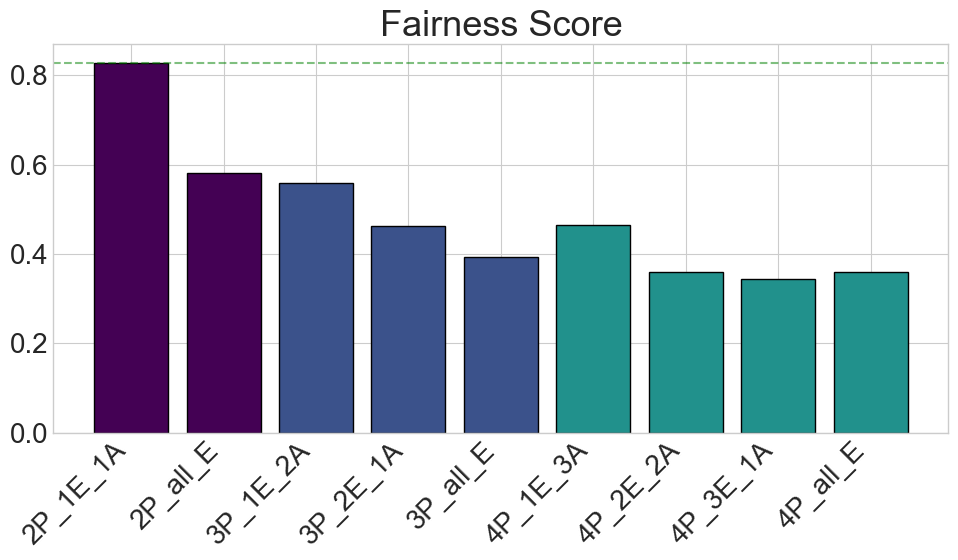

-> Saved: plots/optimal_config/fairness.svg


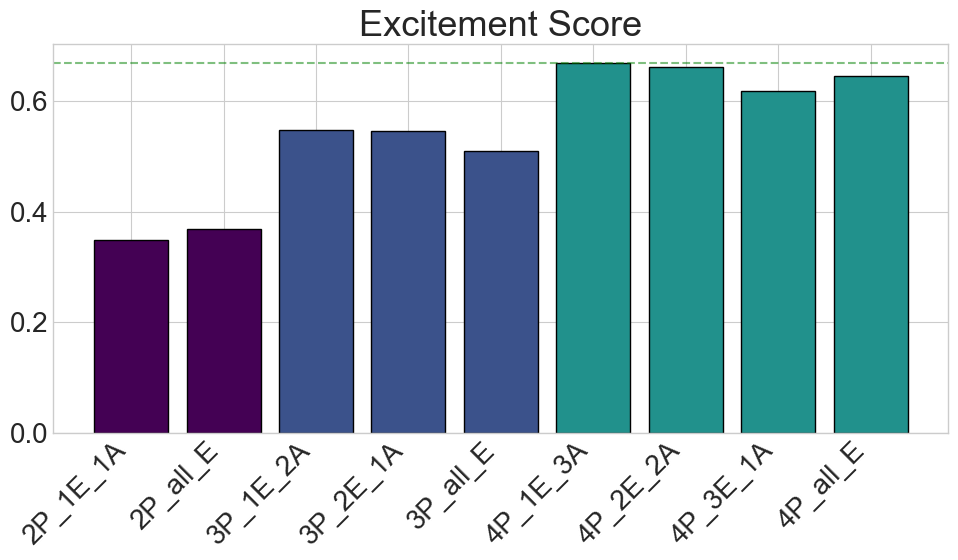

-> Saved: plots/optimal_config/excitement.svg


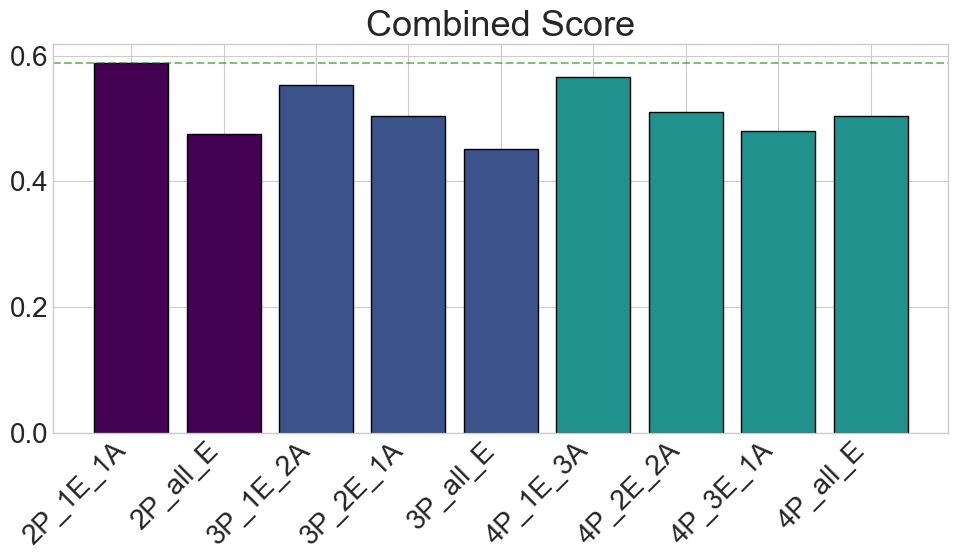

-> Saved: plots/optimal_config/combined.svg


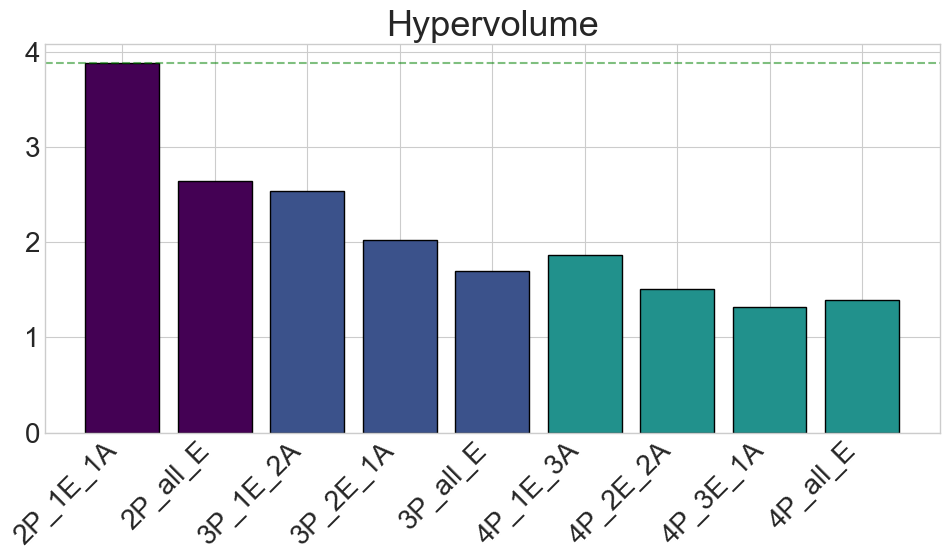

-> Saved: plots/optimal_config/hypervolume.svg


In [13]:
# Create separate SVG for each metric
names = list(all_results.keys())
colors = [plt.cm.viridis((all_results[n]['config']['n_players']-2)/4) for n in names]

metrics_data = [
    ([all_results[n]['fairness_score'] for n in names], 'Fairness Score', 'fairness'),
    ([all_results[n]['excitement_score'] for n in names], 'Excitement Score', 'excitement'),
    ([all_results[n]['combined_score'] for n in names], 'Combined Score', 'combined'),
    ([all_results[n]['hypervolume'] for n in names], 'Hypervolume', 'hypervolume')
]

for metric, title, filename in metrics_data:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(range(len(names)), metric, color=colors, edgecolor='black')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_title(title)
    ax.axhline(max(metric), color='green', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'{filename}.svg', format='svg', bbox_inches='tight')
    plt.show()
    print(f"-> Saved: {PLOTS_DIR / f'{filename}.svg'}")

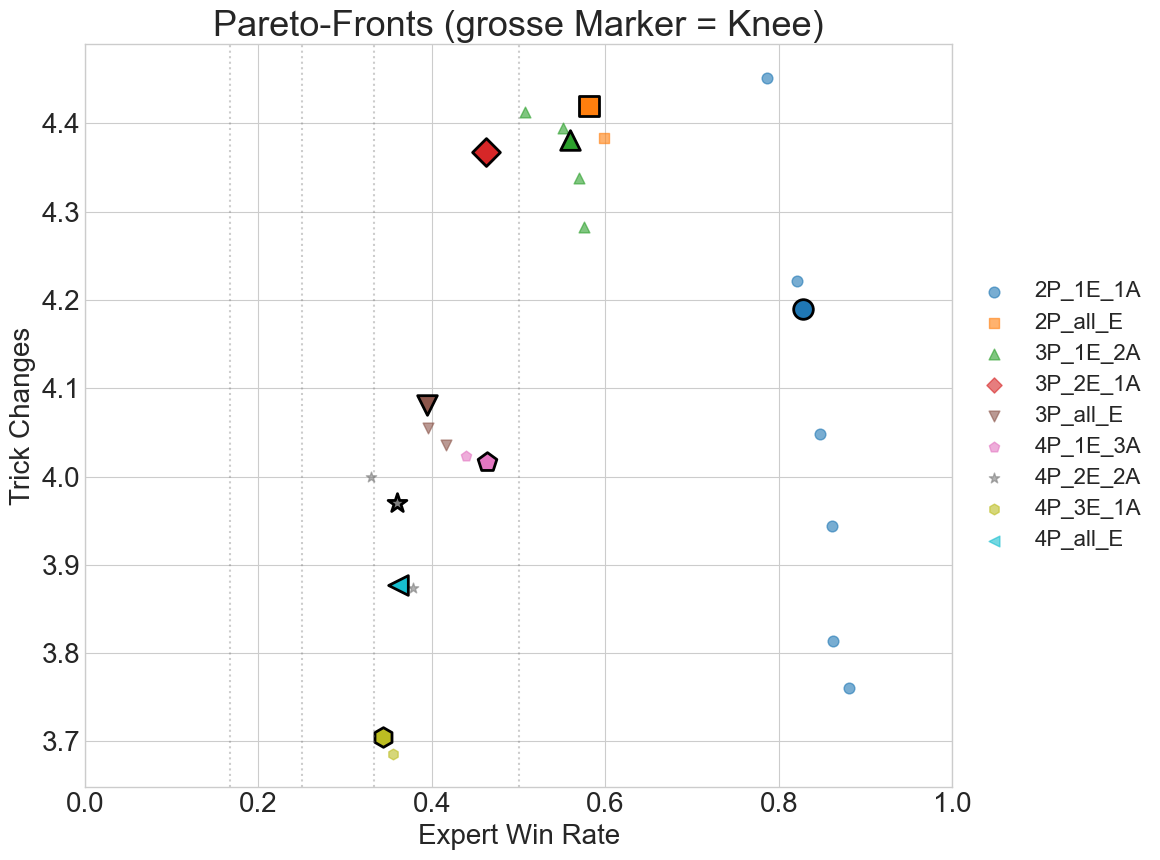

In [14]:
fig, ax = plt.subplots(figsize=(12, 9))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', '<', '>']

for i, (name, r) in enumerate(all_results.items()):
    df, knee = r['validated_df'], r['knee_point']
    ax.scatter(df['focus_expert_win_rate'], df['trick_changes'], c=[colors[i]], marker=markers[i%len(markers)],
               s=60, alpha=0.6, label=name)
    ax.scatter(knee['focus_expert_win_rate'], knee['trick_changes'], c=[colors[i]], marker=markers[i%len(markers)],
               s=200, edgecolors='black', linewidth=2)

for n in [2,3,4,6]:
    ax.axvline(1/n, color='gray', linestyle=':', alpha=0.4)

ax.set_xlabel('Expert Win Rate')
ax.set_ylabel('Trick Changes')
ax.set_title('Pareto-Fronts (grosse Marker = Knee)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'all_pareto_fronts.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Heatmap

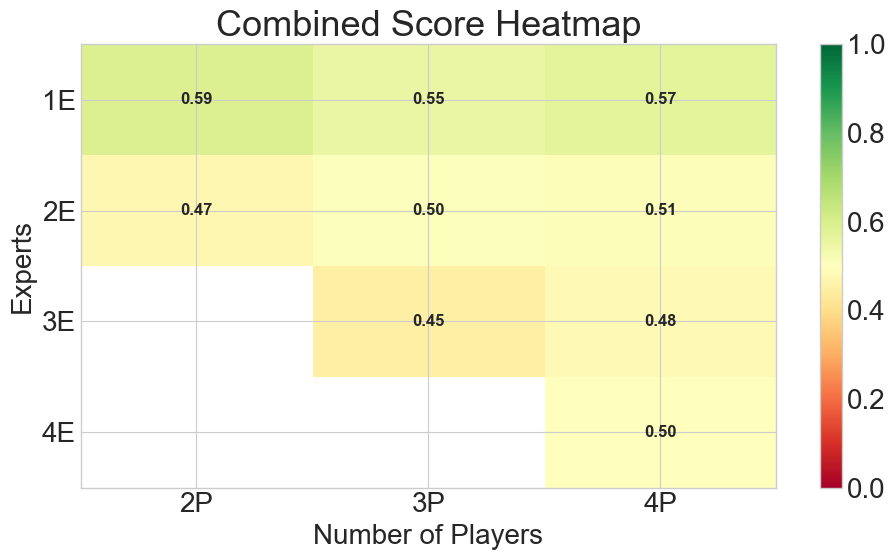

In [15]:
player_counts = sorted(set(r['config']['n_players'] for r in all_results.values()))
max_exp = max(r['config']['n_experts'] for r in all_results.values())
combined_matrix = np.full((max_exp, len(player_counts)), np.nan)

for name, r in all_results.items():
    col = player_counts.index(r['config']['n_players'])
    row = r['config']['n_experts'] - 1
    combined_matrix[row, col] = r['combined_score']

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(combined_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(player_counts)))
ax.set_xticklabels([f'{p}P' for p in player_counts])
ax.set_yticks(range(max_exp))
ax.set_yticklabels([f'{i+1}E' for i in range(max_exp)])
ax.set_xlabel('Number of Players')
ax.set_ylabel('Experts')
ax.set_title('Combined Score Heatmap')
for i in range(max_exp):
    for j in range(len(player_counts)):
        if not np.isnan(combined_matrix[i, j]):
            ax.text(j, i, f'{combined_matrix[i, j]:.2f}', ha='center', va='center', fontsize=12, fontweight='bold')
plt.colorbar(im)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Speichern

In [16]:
# Export mit Python-Typen (keine numpy)
export = {}
for name, r in all_results.items():
    export[name] = to_python_types({
        'config': r['config'],
        'hypervolume': r['hypervolume'],
        'knee_point': r['knee_point'],
        'fairness_score': r['fairness_score'],
        'excitement_score': r['excitement_score'],
        'combined_score': r['combined_score'],
        'stats': r['stats']
    })

export = to_python_types(export)
with open(RESULTS_DIR / 'optimal_config_results.json', 'w') as f:
    json.dump(export, f, indent=2)

rankings = to_python_types({
    'best_fairness': best_fair[0],
    'best_excitement': best_excite[0],
    'best_combined': best_comb[0],
    'best_hypervolume': best_hv[0],
    'K': K, 'L': L
})
with open(RESULTS_DIR / 'rankings.json', 'w') as f:
    json.dump(rankings, f, indent=2)

results_df.to_csv(RESULTS_DIR / 'results_table.csv', index=False)
print('Gespeichert!')

Gespeichert!


## 10. Zusammenfassung

In [17]:
print('\n' + '='*60)
print(f'RESULT: OPTIMAL CONFIGURATION (K={K}, L={L})')
print('='*60)
print(f'\n>>> RECOMMENDATION: {best_comb[0]} <<<')
print(f'    {best_comb[1]["config"]["n_players"]} Players:')
print(f'    {best_comb[1]["config"]["n_experts"]}E vs {best_comb[1]["config"]["n_beginners"]}A')
print(f'\n    Knee Point:')
print(f'    - Focus Expert WR: {best_comb[1]["knee_point"]["focus_expert_win_rate"]:.1%}')
print(f'    - Trick Ch.: {best_comb[1]["knee_point"]["trick_changes"]:.2f}')
print(f'\n    Scores:')
print(f'    - Fairness:   {best_comb[1]["fairness_score"]:.1%}')
print(f'    - Excitement: {best_comb[1]["excitement_score"]:.1%}')
print(f'    - Combined:   {best_comb[1]["combined_score"]:.1%}')
print('='*60)


RESULT: OPTIMAL CONFIGURATION (K=24, L=4)

>>> RECOMMENDATION: 2P_1E_1A <<<
    2 Players:
    1E vs 1A

    Knee Point:
    - Focus Expert WR: 82.8%
    - Trick Ch.: 4.19

    Scores:
    - Fairness:   82.8%
    - Excitement: 34.9%
    - Combined:   58.9%
